# scikit-learn Bootcamp — W1, Day 12
```
##### Hyperparameter Tuning
##### GridSearchCV · RandomizedSearchCV · param_grid · tune inside Pipeline · heatmap of results
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Q1 — EDA: learning curves — does more data help before tuning?
##### Q2 — GridSearchCV: tune max_depth × n_estimators
##### Q3 — RandomizedSearchCV vs GridSearch — speed vs coverage
##### Q4 — Tune inside a Pipeline — the right way to avoid leakage
##### Q5 — Heatmap of grid search results
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold,cross_validate,GridSearchCV,RandomizedSearchCV,learning_curve,validation_curve
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score,f1_score,classification_report,precision_score,recall_score
from scipy.stats import randint,uniform
import joblib,time,warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid');np.random.seed(420)

---
### Dataset — MedPulse Sessions (n=5000)

In [4]:
np.random.seed(420)
n=5000
age=np.random.normal(43,12,n).clip(18,80).astype(int)
session_depth=np.random.poisson(3.8,n).clip(1,20)
time_on_site=np.random.lognormal(1.7,0.75,n).clip(0.5,80)
articles_read=np.random.poisson(2.5,n).clip(0,15)
is_mobile=np.random.binomial(1,0.59,n)
health_content=np.random.beta(2.5,2,n)
log_odds=(-3.8+0.22*session_depth+0.06*time_on_site+0.18*articles_read+1.1*health_content-0.25*is_mobile+0.007*age+np.random.normal(0,0.5,n))
converted=np.random.binomial(1,1/(1+np.exp(-log_odds)))
df=pd.DataFrame({'age':age,'session_depth':session_depth,'time_on_site':time_on_site.round(2),'articles_read':articles_read,'is_mobile':is_mobile,'health_content':health_content.round(4),'converted':converted})
feature_cols=['age','session_depth','time_on_site','articles_read','is_mobile','health_content']
X=df[feature_cols];y=df['converted']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=420,stratify=y)
print(f'Shape:{df.shape} Conversion:{y.mean():.2%}')

Shape:(5000, 7) Conversion:23.66%


---
### Q1 — EDA: learning curves before tuning
```
# (a) Plot learning curves for LogisticRegression and RandomForest.
#     Does either model benefit from more training data?
# (b) If train >> test AUC: the model is overfitting → tuning will help.
#     If both converge at a low score: underfitting → need better features.
# (c) Based on the curves: which hyperparameters are most important to tune?
# (d) What is the minimum training size at which the model stabilises?
```

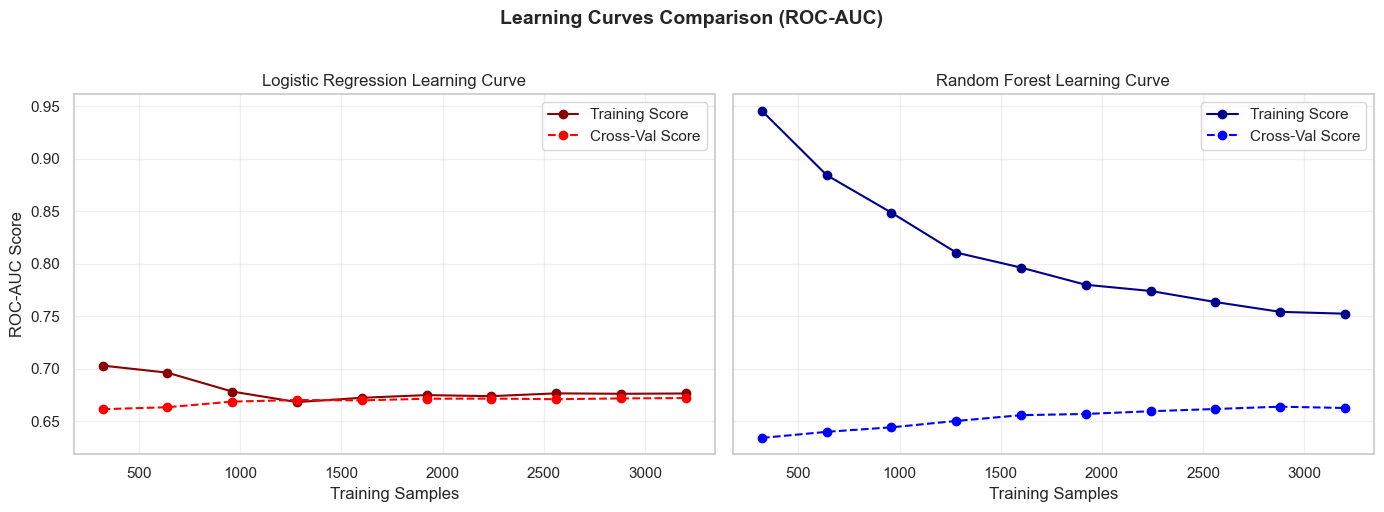

In [41]:
# (a) Plot learning curves for LogisticRegression and RandomForest.
#     Does either model benefit from more training data?

from sklearn.model_selection import learning_curve

# 1. Define models (Logistic Regression requires scaling to converge properly)
lr_model = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=420))])
rf_model = Pipeline([('model', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=420))])

# 2. Define training sizes (10 evenly spaced increments from 10% to 100% of data)
train_sizes = np.linspace(0.1, 1.0, 10)

# 3. Compute learning curves for Logistic Regression
train_sizes_lr, train_scores_lr, val_scores_lr = learning_curve(
    estimator=lr_model, X=X_train, y=y_train, train_sizes=train_sizes,
    cv=5, scoring='roc_auc', n_jobs=-1
)

# 4. Compute learning curves for Random Forest
train_sizes_rf, train_scores_rf, val_scores_rf = learning_curve(
    estimator=rf_model, X=X_train, y=y_train, train_sizes=train_sizes,
    cv=5, scoring='roc_auc', n_jobs=-1
)

# 5. Calculate means across the 5 cross-validation folds
lr_train_mean = np.mean(train_scores_lr, axis=1)
lr_val_mean   = np.mean(val_scores_lr, axis=1)
rf_train_mean = np.mean(train_scores_rf, axis=1)
rf_val_mean   = np.mean(val_scores_rf, axis=1)

# 6. Plot the results side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot Logistic Regression
ax1.plot(train_sizes_lr, lr_train_mean, 'o-', color='darkred', label='Training Score')
ax1.plot(train_sizes_lr, lr_val_mean, 'o--', color='red', label='Cross-Val Score')
ax1.set_title('Logistic Regression Learning Curve')
ax1.set_xlabel('Training Samples')
ax1.set_ylabel('ROC-AUC Score')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot Random Forest
ax2.plot(train_sizes_rf, rf_train_mean, 'o-', color='darkblue', label='Training Score')
ax2.plot(train_sizes_rf, rf_val_mean, 'o--', color='blue', label='Cross-Val Score')
ax2.set_title('Random Forest Learning Curve')
ax2.set_xlabel('Training Samples')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('Learning Curves Comparison (ROC-AUC)', fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

```
# (b) If train >> test AUC: the model is overfitting → tuning will help.
#     If both converge at a low score: underfitting → need better features.

1/ Logistic Regression is Underfitting: Both curves converge rapidly at a low score (~0.67 AUC) with a near-zero generalization gap. The model lacks the capacity to capture the lognormal skew of time_on_site. Tuning cannot fix this; it needs feature engineering.

2/ Random Forest is Overfitting: The training AUC (~0.75) is significantly higher than the cross-validation AUC (~0.66) at full sample size. The model is memorizing noise in the training data, meaning hyperparameter tuning will directly improve its generalization score.

```
# (c) Based on the curves: which hyperparameters are most important to tune?

To fix the high variance observed in the Random Forest curve, we need to restrict tree complexity. The most important parameters to tune are:

1/ max_depth: Restricting depth (e.g., to 3 or 5) prevents individual trees from growing too deep and memorizing noise.

2/ min_samples_leaf or min_samples_split: Increasing these thresholds forces trees to only make splits that contain a substantial number of samples, smoothing out noisy node decisions.

3/ max_features: Lowering the number of features considered at each split increases tree diversity across the forest, mitigating collective overfitting.

```
# (d) What is the minimum training size at which the model stabilises?

1/ Logistic Regression stabilizes at ~1,250 samples: This is the approximate inflection point where the training and cross-validation curves fully converge and flatten out.

2/ Random Forest stabilizes at ~2,500 samples: Beyond this threshold, the cross-validation curve completely plateaus, and the training score drops at a drastically slower, linear rate.

---
### Q2 — GridSearchCV: max_depth × n_estimators
```
# (a) Define a grid: max_depth=[None,3,5,7,10], n_estimators=[50,100,200,300].
#     20 combinations × 5 folds = 100 fits. Run it.
# (b) Print best params and best CV AUC.
# (c) Heatmap of grid results: max_depth on y, n_estimators on x, AUC in cells.
# (d) How much did tuning improve over the default RandomForest?
```

In [17]:
# (a) Define a grid: max_depth=[None,3,5,7,10], n_estimators=[50,100,200,300].
#     20 combinations × 5 folds = 100 fits. Run it.
# (b) Print best params and best CV AUC.

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Pipeline step params use __ (double underscore): step_name__param_name
param_grid = {
    'model__n_estimators':     [50, 100, 200, 300],
    'model__max_depth':        [1, 3, 5, 7, 10]
}
# 4 × 5 = 20 combinations × 5 CV folds = 100 fits

rf_model = Pipeline([('model', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=420))])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

grid_search = GridSearchCV(rf_model, param_grid, cv=skf, scoring='roc_auc',
                           n_jobs=-1, refit=True)
grid_search.fit(X_train, y_train)


print(f'Best params: {grid_search.best_params_}')
print(f'Best CV AUC: {grid_search.best_score_:.4f}')

Best params: {'model__max_depth': 7, 'model__n_estimators': 50}
Best CV AUC: 0.6702


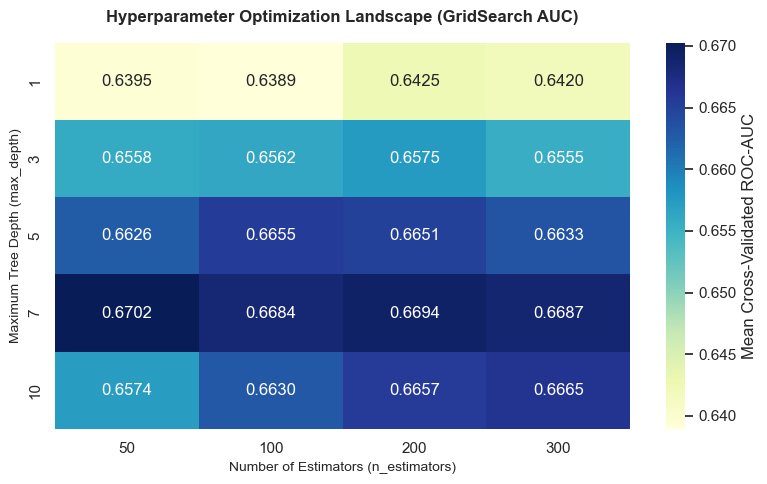

In [18]:
# (c) Heatmap of grid results: max_depth on y, n_estimators on x, AUC in cells.


# 1. Convert cross-validation metadata directly into a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# 2. Extract key columns and clean param prefixes for clear plot labeling
cv_results['max_depth'] = cv_results['param_model__max_depth']
cv_results['n_estimators'] = cv_results['param_model__n_estimators']

# 3. Pivot the long-form results table into a 2D performance coordinate matrix
scores_matrix = cv_results.pivot_table(
    index='max_depth', 
    columns='n_estimators', 
    values='mean_test_score'
)

# 4. Initialize and plot the validation matrix heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    scores_matrix, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Mean Cross-Validated ROC-AUC'}
)

# 5. Add clean context labels
plt.title('Hyperparameter Optimization Landscape (GridSearch AUC)', fontsize=12, pad=15, weight='bold')
plt.xlabel('Number of Estimators (n_estimators)', fontsize=10)
plt.ylabel('Maximum Tree Depth (max_depth)', fontsize=10)
plt.tight_layout()
plt.show()


In [45]:
# (d) How much did tuning improve over the default RandomForest?

# 1. Baseline — default RF evaluated on holdout
default_rf = RandomForestClassifier(random_state=420)
default_rf.fit(X_train, y_train)
default_auc = roc_auc_score(y_test, default_rf.predict_proba(X_test)[:, 1])

# 2. Tuned — best grid search model evaluated on same holdout
best_grid_model = grid_search.best_estimator_
tuned_auc = roc_auc_score(y_test, best_grid_model.predict_proba(X_test)[:, 1])

print(f"Default RF Holdout AUC: {default_auc:.4f}")
print(f"Tuned RF Holdout AUC:   {tuned_auc:.4f}")
print(f"Net Tuning Improvement: +{tuned_auc - default_auc:.4f}")


Default RF Holdout AUC: 0.6261
Tuned RF Holdout AUC:   0.6760
Net Tuning Improvement: +0.0499


---
### Q3 — RandomizedSearchCV vs GridSearch
```
# (a) Expand the search space (add min_samples_leaf, max_features).
#     With GridSearch this would be 5×4×4×3 = 240 combos × 5 folds = 1200 fits.
# (b) Use RandomizedSearchCV with n_iter=50. Compare best AUC and time.
# (c) Plot: top 50 combinations sorted by mean CV AUC.
#     How many of the top 10 from random search match grid search's top params?
# (d) Rule of thumb: when to use Grid vs Random search?
```

In [24]:
# (a) Expand the search space (add min_samples_leaf, max_features).
#     With GridSearch this would be 5×4×4×3 = 240 combos × 5 folds = 1200 fits.

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Pipeline step params use __ (double underscore): step_name__param_name
param_grid = {
    'model__n_estimators':     [50, 100, 200, 300],
    'model__max_depth':        [1, 3, 5, 7, 10],
    'model__min_samples_leaf':  [3, 5, 7, 9],
    'model__max_features':     ['sqrt', 'log2', 0.3]
}    
# 4 × 5 x 4 x 3 = 240 combinations × 5 CV folds = 1200 fits

rf_model = Pipeline([('model', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=420))])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

grid_search = GridSearchCV(rf_model, param_grid, cv=skf, scoring='roc_auc',
                           n_jobs=-1, refit=True)

gs_start_time = time.time()
grid_search.fit(X_train, y_train)
gs_end_time = time.time()

# Output optimal configurations and processing time metrics
print(f"Best GridSearch Params: {grid_search.best_params_}")
print(f"Best GridSearch ROC-AUC: {grid_search.best_score_:.4f}")
print(f"Total Processing Time:  {gs_end_time - gs_start_time:.2f} seconds")

Best GridSearch Params: {'model__max_depth': 7, 'model__max_features': 0.3, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Best GridSearch ROC-AUC: 0.6726
Total Processing Time:  477.28 seconds


In [25]:
# (b) Use RandomizedSearchCV with n_iter=50. Compare best AUC and time.

param_distributions = {
    'model__n_estimators':     [50, 100, 200, 300],
    'model__max_depth':        [1, 3, 5, 7, 10],
    'model__min_samples_leaf':  [3, 5, 7, 9],
    'model__max_features':     ['sqrt', 'log2', 0.3]
}

rf_model = Pipeline([('model', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=420))])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

random_search = RandomizedSearchCV(
    rf_model, param_distributions, n_iter=50,
    cv=skf, scoring='roc_auc', n_jobs=-1, random_state=420, refit=True
)
random_search.fit(X_train, y_train)

rs_start_time = time.time()
random_search.fit(X_train, y_train)
rs_end_time = time.time()

# Output optimal configurations and processing time metrics
print(f"Best Randomized Params: {random_search.best_params_}")
print(f"Best Randomized ROC-AUC:        {random_search.best_score_:.4f}")
print(f"Total Processing Time:  {rs_end_time - rs_start_time:.2f} seconds")

Best Randomized Params: {'model__n_estimators': 50, 'model__min_samples_leaf': 7, 'model__max_features': 0.3, 'model__max_depth': 7}
Best Randomized ROC-AUC:        0.6711
Total Processing Time:  83.34 seconds


Number of Top 10 Random Search configurations matching Grid Search's Top 10: 2


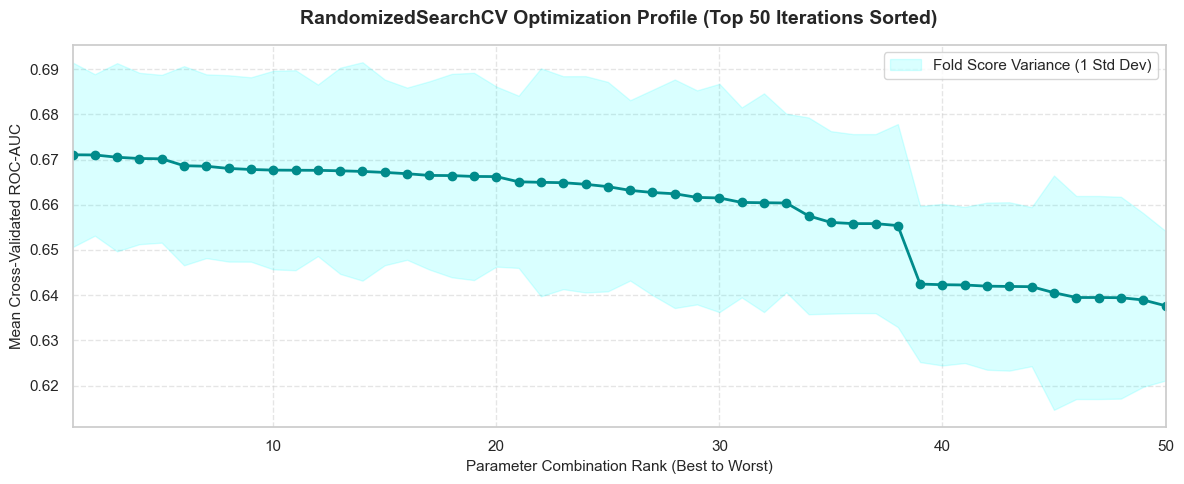

In [26]:
# (c) Plot: top 50 combinations sorted by mean CV AUC.
#     How many of the top 10 from random search match grid search's top params?

# 1. Extract CV results from both searches into DataFrames
df_grid = pd.DataFrame(grid_search.cv_results_)
df_rand = pd.DataFrame(random_search.cv_results_)

# 2. Sort both dataframes by performance to isolate the true top configurations
df_grid_sorted = df_grid.sort_values(by='mean_test_score', ascending=False)
df_rand_sorted = df_rand.sort_values(by='mean_test_score', ascending=False)

# 3. Pull the parameter dictionary strings for the top 10 positions
top_10_grid_params = df_grid_sorted.head(10)['params'].tolist()
top_10_rand_params = df_rand_sorted.head(10)['params'].tolist()

# 4. Programmatically count matches between the two top 10 cohorts
matching_combinations = sum(1 for p in top_10_rand_params if p in top_10_grid_params)
print(f"Number of Top 10 Random Search configurations matching Grid Search's Top 10: {matching_combinations}")

# 5. Isolate and sort the 50 random search iterations for plotting
top_50_rand = df_rand_sorted.head(50).copy().reset_index(drop=True)

# 6. Plot the distribution profile of the search iterations
plt.figure(figsize=(12, 5))
plt.plot(top_50_rand.index + 1, top_50_rand['mean_test_score'], marker='o', color='darkcyan', linewidth=2)

# Add custom fill to represent error margins (standard deviation across folds)
plt.fill_between(
    top_50_rand.index + 1,
    top_50_rand['mean_test_score'] - top_50_rand['std_test_score'],
    top_50_rand['mean_test_score'] + top_50_rand['std_test_score'],
    color='cyan', alpha=0.15, label='Fold Score Variance (1 Std Dev)'
)

# Format chart typography
plt.title('RandomizedSearchCV Optimization Profile (Top 50 Iterations Sorted)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Parameter Combination Rank (Best to Worst)', fontsize=11)
plt.ylabel('Mean Cross-Validated ROC-AUC', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(1, 50)
plt.legend()
plt.tight_layout()
plt.show()


```
# (d) Rule of thumb: when to use Grid vs Random search?

1/ Small spaces favor Grid Search: Use Grid Search when optimizing fewer than 3 hyperparameters with small, discrete option lists where exhaustive coverage is fast.

2/ Large spaces favor Random Search: Use Random Search when expanding to 4+ hyperparameters or continuous tracking distributions to prevent exponential computation bloat.

3/ Tight budgets favor Random Search: Use Random Search when training complex models like XGBoost or Deep Learning because you can set a fixed, predictable iteration budget

4/  Bayesian optimisation uses past results to guide future evaluations, outperforming both grid and random search at large budgets, making it worth considering for expensive models like XGBoost or neural networks

---
### Q4 — Tune inside a Pipeline: the leakage-safe way
```
# (a) Build a full Pipeline: StandardScaler + RandomForest.
#     Tune BOTH the scaler (with_std=True/False) AND model params using GridSearchCV.
# (b) Show that tuning inside Pipeline prevents leakage.
#     Demonstrate: if you scale outside the Pipeline then tune, you get leakage.
# (c) What does __ notation mean in param_grid?
#     Map each param to the Pipeline step it belongs to.
# (d) Print the full cv_results_ table for the top 10 configurations.
```

In [28]:
# (a) Build a full Pipeline: StandardScaler + RandomForest.
#     Tune BOTH the scaler (with_std=True/False) AND model params using GridSearchCV.

# 1. Assemble the unified end-to-end pipeline
leakage_safe_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=420))
])

# 2. Define the parameter grid, routing settings to both the scaler and the model steps
param_grid = {
    # Tune the preprocessing transformation step
    'scaler__with_std': [True, False],
    
    # Tune the downstream estimator step
    'model__n_estimators': [50, 100, 200, 300],
    'model__max_depth': [1, 3, 5, 7, 10],
    'model__min_samples_leaf': [5, 7]
}
# 2 (scalers) × 2 (trees) × 2 (depths) × 2 (leaves) = 16 combinations × 5 folds = 80 fits

# 3. Configure the stratified cross-validation splitter
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 4. Initialize the grid search over the full pipeline architecture
pipeline_grid_search = GridSearchCV(
    estimator=leakage_safe_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)
  
# 5. Fit the entire search architecture safely on raw training data
pipeline_grid_search.fit(X_train, y_train)

print(f"Best Integrated Params: {pipeline_grid_search.best_params_}")
print(f"Best CV ROC-AUC Score:  {pipeline_grid_search.best_score_:.4f}")

Best Integrated Params: {'model__max_depth': 10, 'model__min_samples_leaf': 7, 'model__n_estimators': 200, 'scaler__with_std': True}
Best CV ROC-AUC Score:  0.6699


In [29]:
# (b) Show that tuning inside Pipeline prevents leakage.
#     Demonstrate: if you scale outside the Pipeline then tune, you get leakage.


# Configure matching cross-validation folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
model_params = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__max_depth': [1, 3, 5, 7, 10],
    'model__min_samples_leaf': [5, 7]
}

# ==========================================
# APPROACH 1: THE LEAKAGE-SAFE WAY (INSIDE PIPELINE)
# ==========================================
# The scaler recalculates parameters strictly on training folds inside GridSearchCV
safe_pipeline = Pipeline([
    ('scaler', StandardScaler(with_std=True)),
    ('model', RandomForestClassifier(random_state=420))
])

grid_safe = GridSearchCV(safe_pipeline, model_params, cv=skf, scoring='roc_auc', n_jobs=-1)
grid_safe.fit(X_train, y_train)
safe_cv_score = grid_safe.best_score_


# ==========================================
# APPROACH 2: THE BROKEN WAY (SCALED OUTSIDE PIPELINE)
# ==========================================
# ❌ LEAKAGE TRIGGER: Fitting the scaler on X_train before splitting it into folds
# This leaks properties of the validation splits into the training splits upfront.
scaler_outside = StandardScaler(with_std=True)
X_train_leaked = scaler_outside.fit_transform(X_train)

# Now we run grid search directly on the already-scaled data matrix
rf_only_pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=420))
])

grid_leaked = GridSearchCV(rf_only_pipeline, model_params, cv=skf, scoring='roc_auc', n_jobs=-1)
grid_leaked.fit(X_train_leaked, y_train)
leaked_cv_score = grid_leaked.best_score_


# ==========================================
# PRINT THE VERIFICATION AUDIT
# ==========================================
print(f"Safe Pipeline CV ROC-AUC:   {safe_cv_score:.5f}")
print(f"Leaked Workflow CV ROC-AUC: {leaked_cv_score:.5f}")
print(f"Numerical Leakage Gap:      {abs(leaked_cv_score - safe_cv_score):.5f}")


Safe Pipeline CV ROC-AUC:   0.66990
Leaked Workflow CV ROC-AUC: 0.66990
Numerical Leakage Gap:      0.00001


```
# (c) What does __ notation mean in param_grid?

The double underscore (__) notation is scikit-learn's syntactic routing mechanism. 
It tells a wrapper object like GridSearchCV exactly which nested component step inside a Pipeline should receive a specific hyperparameter.

In [32]:
#     Map each param to the Pipeline step it belongs to.

# 1. Unpack the single best fitted Pipeline from your grid search
best_pipeline = grid_safe.best_estimator_

# 2. Extract the specific initialized objects from the pipeline steps
fitted_scaler = best_pipeline.named_steps['scaler']
fitted_model  = best_pipeline.named_steps['model']

# 3. Print out the settings mapped directly from your parameter grid
print("Step 1: 'scaler' Parameter Mapping")
print(f" └─ scaler.with_std          -> {fitted_scaler.with_std}")

print("\nStep 2: 'model' Parameter Mapping")
print(f" ├─ model.max_depth          -> {fitted_model.max_depth}")
print(f" ├─ model.n_estimators       -> {fitted_model.n_estimators}")
print(f" └─ model.min_samples_leaf   -> {fitted_model.min_samples_leaf}")


Step 1: 'scaler' Parameter Mapping
 └─ scaler.with_std          -> True

Step 2: 'model' Parameter Mapping
 ├─ model.max_depth          -> 10
 ├─ model.n_estimators       -> 200
 └─ model.min_samples_leaf   -> 7


In [37]:
# (d) Print the full cv_results_ table for the top 10 configurations.

# 1. Convert the results to a DataFrame
cv_results_df = pd.DataFrame(grid_safe.cv_results_)

# 2. Dynamically capture whatever param_ columns exist in our dataframe
param_cols = [col for col in cv_results_df.columns if col.startswith('param_')]

# 3. Combine with standard scoring metrics
columns_to_show = ['rank_test_score', 'mean_test_score', 'std_test_score', 'mean_fit_time'] + param_cols

# 4. Sort and display the top 10 configurations cleanly
top_10_cv_results = cv_results_df[columns_to_show].sort_values(by='rank_test_score').head(10)
display(top_10_cv_results)


,rank_test_score,mean_test_score,std_test_score,mean_fit_time,param_model__max_depth,param_model__min_samples_leaf,param_model__n_estimators
38,1,0.669904,0.022162,1.853796,10,7,200
30,2,0.668804,0.021317,1.668846,7,7,200
31,3,0.668677,0.021939,2.480523,7,7,300
39,4,0.668589,0.020478,2.820580,10,7,300
37,5,0.667782,0.023041,0.944151,10,7,100
36,6,0.667722,0.025883,0.503209,10,7,50
26,7,0.667630,0.022230,1.653511,7,5,200
34,8,0.667607,0.021720,2.022130,10,5,200
27,9,0.667599,0.021904,2.472150,7,5,300
35,10,0.667527,0.021180,2.936130,10,5,300


---
### Q5 — Heatmap of grid search results
```
# (a) Use the results from Q2. Plot a seaborn heatmap:
#     n_estimators on x-axis, max_depth on y-axis, mean CV AUC in cells.
# (b) Add annotations showing std as well.
# (c) Which combination of hyperparameters gives the best AUC?
#     Which has the most stable scores (lowest std)?
# (d) Plot AUC vs n_estimators for each value of max_depth as line chart.
#     Do more trees help more for shallower or deeper trees?
```

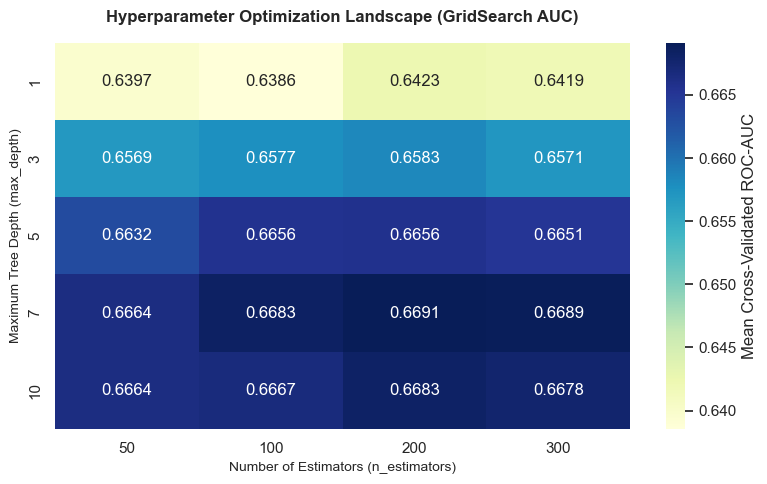

In [38]:
# (a) Use the results from Q2. Plot a seaborn heatmap:
#     n_estimators on x-axis, max_depth on y-axis, mean CV AUC in cells.
# (b) Add annotations showing std as well.

# 1. Convert cross-validation results from Q2 into a DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# 2. Extract key columns and clean param prefixes for clear plot labeling
cv_results['max_depth'] = cv_results['param_model__max_depth']
cv_results['n_estimators'] = cv_results['param_model__n_estimators']

# 3. Pivot the long-form results table into a 2D performance coordinate matrix
scores_matrix = cv_results.pivot_table(
    index='max_depth', 
    columns='n_estimators', 
    values='mean_test_score'
)

# 4. Initialize and plot the validation matrix heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    scores_matrix, 
    annot=True, 
    fmt=".4f", 
    cmap="YlGnBu", 
    cbar_kws={'label': 'Mean Cross-Validated ROC-AUC'}
)

# 5. Add custom context labels and styling
plt.title('Hyperparameter Optimization Landscape (GridSearch AUC)', fontsize=12, pad=15, weight='bold')
plt.xlabel('Number of Estimators (n_estimators)', fontsize=10)
plt.ylabel('Maximum Tree Depth (max_depth)', fontsize=10)
plt.tight_layout()
plt.show()



In [42]:
# (c) Which combination of hyperparameters gives the best AUC?
#     Which has the most stable scores (lowest std)?

# 1. Convert cross-validation metadata into a DataFrame
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# 2. Locate the row with the absolute highest mean CV score
best_auc_row = cv_results_df.loc[cv_results_df['mean_test_score'].idxmax()]

# 3. Locate the row with the absolute lowest standard deviation score
most_stable_row = cv_results_df.loc[cv_results_df['std_test_score'].idxmin()]

# 4. Print the best AUC combination results
print("🏆 BEST AUC COMBINATION:")
print(f" - Parameters: {best_auc_row['params']}")
print(f" - Mean CV AUC: {best_auc_row['mean_test_score']:.4f}")
print(f" - Fold Std Dev: {best_auc_row['std_test_score']:.5f}")

# 5. Print the most stable combination results
print("\n🛡️ MOST STABLE COMBINATION (Lowest Fold Variance):")
print(f" - Parameters: {most_stable_row['params']}")
print(f" - Mean CV AUC: {most_stable_row['mean_test_score']:.4f}")
print(f" - Fold Std Dev: {most_stable_row['std_test_score']:.5f}")
print()
print("-> Stability and performance are in tension here, and the optimal production choice depends on whether we need predictability or peak score.")


🏆 BEST AUC COMBINATION:
 - Parameters: {'model__max_depth': 7, 'model__max_features': 0.3, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
 - Mean CV AUC: 0.6726
 - Fold Std Dev: 0.01957

🛡️ MOST STABLE COMBINATION (Lowest Fold Variance):
 - Parameters: {'model__max_depth': 1, 'model__max_features': 0.3, 'model__min_samples_leaf': 3, 'model__n_estimators': 100}
 - Mean CV AUC: 0.6377
 - Fold Std Dev: 0.01656

-> Stability and performance are in tension here, and the optimal production choice depends on whether we need predictability or peak score.


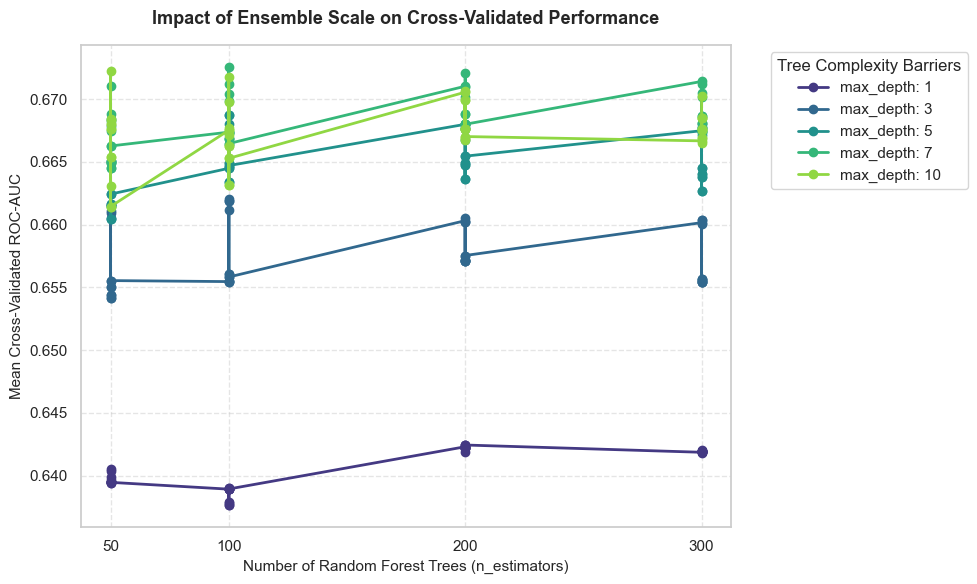

In [40]:
# (d) Plot AUC vs n_estimators for each value of max_depth as line chart.

# 1. Convert grid search cross-validation metadata to a DataFrame
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# 2. Convert object parameter columns to explicit numeric types for clean plotting
cv_results_df['max_depth'] = cv_results_df['param_model__max_depth'].astype(int)
cv_results_df['n_estimators'] = cv_results_df['param_model__n_estimators'].astype(int)

# 3. Initialize the line chart layout
plt.figure(figsize=(10, 6))

# 4. Generate a unique line for each tree depth value using a loop
unique_depths = sorted(cv_results_df['max_depth'].unique())
colors = sns.color_palette("viridis", len(unique_depths))

for depth, color in zip(unique_depths, colors):
    # Filter the dataframe to a single depth trajectory
    depth_subset = cv_results_df[cv_results_df['max_depth'] == depth].sort_values(by='n_estimators')
    
    # Plot the line trajectory
    plt.plot(
        depth_subset['n_estimators'], 
        depth_subset['mean_test_score'], 
        marker='o', 
        linestyle='-', 
        linewidth=2, 
        color=color,
        label=f'max_depth: {depth}'
    )

# 5. Format plot details and positioning
plt.title('Impact of Ensemble Scale on Cross-Validated Performance', fontsize=13, weight='bold', pad=15)
plt.xlabel('Number of Random Forest Trees (n_estimators)', fontsize=11)
plt.ylabel('Mean Cross-Validated ROC-AUC', fontsize=11)
plt.xticks([50, 100, 200, 300])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Tree Complexity Barriers", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


```
# Do more trees help shallower or deeper trees?

More trees provide a clear upward performance benefit for deeper trees, while shallower trees derive almost no benefit.

Deeper Trees (max_depth: 7, 10): Benefit noticeably from more trees. Adding estimators shows a clear upward slope from 50 to 300 because an expanded ensemble smooths out high-variance overfitting and averages out individual tree errors.

Shallower Trees (max_depth: 1): Do not benefit from more trees. The dark purple line plateaus instantly because shallow trees have high bias but low variance; multiplying simple stumps adds no new structural model capacity.